In [14]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append("..\..\..")

from src.pricer import *
MarketData.initialize()

In [7]:
und = Stock.MONEY_MALL
ls = LongShort.LONG
strike = 1.1
expiry = 1
strike_level = strike * MarketData.get_spot()[und]

model = FlatVolModel(und)

contract_opt = EuropeanContract(und, PutCallFwd.CALL, ls, strike_level, expiry)

pricer_opt_an = EuropeanAnalyticPricer(contract_opt, model, Params())

mc_params = MCParams(num_of_path=10000,
                     tenor_frequency= 4,
                     antithetic=False,
                     standardize=False,
                     control_variate=False,
                     seed=1,
                     evolve_spot_method=MCNumMethod.MILSTEIN)

pricer_opt_mc = GenericMCPricer(contract_opt, model, mc_params)

fv_opt_an = pricer_opt_an.calc_fair_value()
fv_opt_mc = pricer_opt_mc.calc_fair_value_with_ci()

pricer_opt_mc.params.evolve_spot_method = MCNumMethod.EULER
fv_opt_mc_e = pricer_opt_mc.calc_fair_value_with_ci()

print("OPTION AN: " + str(fv_opt_an))
print("OPTION MC Milstein: " + str(fv_opt_mc))
print("OPTION MC Euler: " + str(fv_opt_mc_e))

OPTION AN: 48.61310036188887
OPTION MC Milstein: (46.94346424095281, (44.980092743764644, 48.90683573814096))
OPTION MC Euler: (48.398201750408916, (46.554035689012196, 50.24236781180564))


In [17]:
tenors = [4,10,20,30,100,200,252]
error_euler = []
error_milstein = []
for t in tenors:
    mc_params = MCParams(num_of_path=10000,
                         tenor_frequency= t,
                         antithetic=False,
                         standardize=False,
                         control_variate=False,
                         seed=1,
                         evolve_spot_method=MCNumMethod.EXACT)

    ex_model = MCMethodFlatVol(contract_opt, model, mc_params)
    ex_paths = ex_model.simulate_spot_paths()

#convergence for Euler

    mc_params.evolve_spot_method = MCNumMethod.EULER
    eu_model = MCMethodFlatVol(contract_opt, model, mc_params)
    eu_paths = eu_model.simulate_spot_paths()

    abs_err = np.abs(eu_paths[:,-1] - ex_paths[:,-1])

    strong_convergence_error = np.mean(abs_err)

    error_euler.append(strong_convergence_error)

#convergence for Milstein

    mc_params.evolve_spot_method = MCNumMethod.MILSTEIN

    mi_model = MCMethodFlatVol(contract_opt, model, mc_params)
    mi_paths = mi_model.simulate_spot_paths()

    abs_err = np.abs(mi_paths[:,-1] - ex_paths[:,-1])

    strong_convergence_error = np.mean(abs_err)

    error_milstein.append(strong_convergence_error)



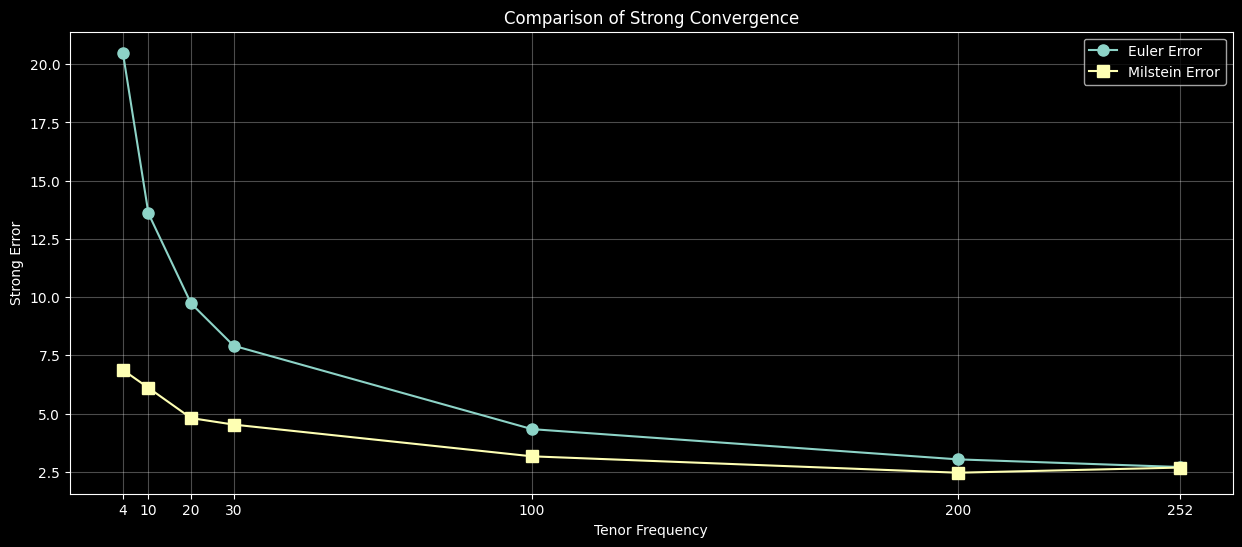

In [28]:
plt.figure(figsize=(15, 6))

plt.plot(tenors, error_euler, 'o-', label='Euler Error', markersize=8)
plt.plot(tenors, error_milstein, 's-', label='Milstein Error', markersize=8)

plt.xlabel('Tenor Frequency')
plt.ylabel('Strong Error')
plt.title('Comparison of Strong Convergence')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.xticks(tenors, [str(t) for t in tenors])
plt.legend()
plt.show()

In [20]:
print(error_euler)
print(error_milstein)

[20.493229085288064, 13.591365005521657, 9.728151426314012, 7.911289455674083, 4.3303610934749726, 3.031980922598134, 2.7042002608956093]
[6.872705756991138, 6.1039168218343365, 4.805751176603217, 4.525106728616995, 3.1629692551489503, 2.4588430339038125, 2.6797420434078267]
